# Read in data

In [251]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pylatexenc.latexencode import unicode_to_latex as text2latex


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()

# Read and clean the data
df = pd.read_csv("../data/qualtrics_experiments/ssl_stimuli_check_August+23,+2025_11.23.csv")
df = df.iloc[2:]  # Skip first two rows (Qualtrics headers)
df = df.query("Status != 'Survey Preview'")

print("Data shape after cleaning:", df.shape)

def is_lm_col(col_name):
    """Check if column follows loop merge pattern: NUMBER_variable_name"""
    parts = col_name.split("_")
    if len(parts) < 2:
        return False

    try:
        first_part = int(parts[0])
        return 1 <= first_part <= 42  # Assuming max 42 loop items
    except ValueError:
        return False

def get_metadata_lm_col(col_name):
    """Extract metadata from loop merge column name"""
    parts = col_name.split("_")
    lm_num = int(parts[0])

    # Determine dataset based on column name
    if "sc_" in col_name:
        dataset = "social_chem"
    elif "norm_" in col_name:
        dataset = "normbank"
    else:
        dataset = "unknown"

    # Determine variable type
    if "qual_why" in col_name:
        var_type = "qual_why"
    elif "agree" in col_name:
        var_type = "agree"
    elif "straight" in col_name:
        var_type = "straight"
    elif "compel_1" in col_name:
        var_type = "compel_ai"
    elif "compel_2" in col_name:
        var_type = "compel_human"
    else:
        var_type = "unknown"

    return lm_num, dataset, var_type

def extract_number(data_value):
    """Extract numeric data from various formats."""
    if pd.isna(data_value):
        return None

    if isinstance(data_value, (int, float)):
        return float(data_value)

    if isinstance(data_value, str):
        data_value = str(data_value).strip()
        if data_value == '' or data_value.lower() == 'nan':
            return None

        matches = re.findall(r'-?\d+(?:\.\d+)?', data_value)
        if matches:
            return float(matches[0])

    return None

# Find all loop merge columns
lm_cols = [c for c in df.columns if is_lm_col(c)]
print(f"Found {len(lm_cols)} loop merge columns")

# Build wide format directly
wide_rows = []

for i, row in df.iterrows():
    pid = row.get('prolific_id')

    # Skip rows with missing PIDs
    if pd.isna(pid) or str(pid).strip() == '':
        print(f"Skipping row {i}: missing PID")
        continue

    pid = str(pid).strip()

    # Get participant-level variables (same for all stimuli)
    llm_usage = row.get('llm_usage')
    viewing_order = row.get('first')
    which_ai = row.get('which_ai')
    which_natural = row.get('which_natural')
    which_ai_qual = row.get('which_ai_qual')

    # Group loop merge columns by stimuli (lm_num + dataset)
    stimuli_data = {}

    for col in lm_cols:
        try:
            lm_num, dataset, var_type = get_metadata_lm_col(col)
            val = row[col]

            # Create unique stimuli identifier
            stimuli_key = f"{lm_num}-{dataset}"

            # Initialize stimuli dict if not exists
            if stimuli_key not in stimuli_data:
                stimuli_data[stimuli_key] = {
                    'lm_num': lm_num,
                    'dataset': dataset
                }

            # Process and store the value
            if var_type == "qual_why":
                processed_val = val if pd.notna(val) and str(val).strip() != '' else None
            else:
                processed_val = extract_number(val)

            stimuli_data[stimuli_key][var_type] = processed_val

        except Exception as e:
            print(f"Error processing column {col} for PID {pid}: {e}")
            continue

    # Create one row per stimuli for this participant
    for stimuli_key, stimuli_info in stimuli_data.items():
        wide_row = {
            'pid': pid,
            'pid_stimuli': f"{pid}-{stimuli_key}",
            'lm_num': stimuli_info['lm_num'],
            'dataset': stimuli_info['dataset'],
            'llm_usage': llm_usage,
            'viewing_order': viewing_order,
            'which_ai': which_ai,
            'which_natural': which_natural,
            'which_ai_qual': which_ai_qual,
            # Add all the variable types as columns
            'agree': stimuli_info.get('agree'),
            'straight': stimuli_info.get('straight'),
            'compel_ai': stimuli_info.get('compel_ai'),
            'compel_human': stimuli_info.get('compel_human'),
            'compel_human_diff': (stimuli_info.get('compel_human') - stimuli_info.get('compel_ai')
                                   if stimuli_info.get('compel_human') is not None and stimuli_info.get('compel_ai') is not None
                                   else None),
            'qual_why': stimuli_info.get('qual_why')
        }
        wide_rows.append(wide_row)

    print(f"Processed PID {pid}: {len(stimuli_data)} stimuli")

# Convert to DataFrame
df_wide = pd.DataFrame(wide_rows)
df_wide = df_wide.dropna(subset=['compel_ai'])

print(f"\nFinal wide format:")
print(f"Shape: {df_wide.shape}")
print(f"Unique PIDs: {df_wide['pid'].nunique()}")
print(f"Unique datasets: {df_wide['dataset'].unique()}")
print(f"Columns: {list(df_wide.columns)}")

# Display sample
print("\nSample of wide format data:")
print(df_wide.head())

# Check missing data patterns
print("\nMissing data summary:")
response_cols = ['agree', 'straight', 'compel_ai', 'compel_human', 'qual_why']
for col in response_cols:
    if col in df_wide.columns:
        missing_count = df_wide[col].isna().sum()
        total_count = len(df_wide)
        print(f"{col}: {missing_count}/{total_count} missing ({missing_count/total_count*100:.1f}%)")

# Summary by participant
print(f"\nParticipant summary:")
print(f"Original participants after filtering: {len(df)}")
print(f"Participants with valid stimuli data: {df_wide['pid'].nunique()}")
print(f"Total stimuli responses: {len(df_wide)}")
print(f"Average stimuli per participant: {len(df_wide) / df_wide['pid'].nunique():.1f}")

# Show distribution by dataset
dataset_counts = df_wide['dataset'].value_counts()
print(f"\nStimuli by dataset:")
print(dataset_counts)



# merge with metadata
meta_df = pd.read_csv("../data/qualtrics_experiments/compare_stimuli_lm_clean.csv")
df_wide = pd.merge(df_wide, meta_df, how='inner', left_on=['lm_num'], right_on=['idx'])


# shown stimuli
# social_chemistry_stimulus_rewrite if dataset=="social_chem" else normbank_stimulus_rewrite

df_wide['shown_stimulus'] = df_wide.apply(
    lambda x: x['social_chemistry_stimulus_rewrite'] if x['dataset']=="social_chem" else x['normbank_stimulus_rewrite'],
    axis=1
)

Data shape after cleaning: (20, 444)
Found 420 loop merge columns
Processed PID 5d617ba9364f9a0019f1dac3: 84 stimuli
Processed PID 606492360e422d12dc63000e: 84 stimuli
Processed PID 5cb5e6927a92c500015c0de1: 84 stimuli
Processed PID 62b628e4351d179f1ff6cc59: 84 stimuli
Processed PID 60dfd857e293a99dd577f4c8: 84 stimuli
Processed PID 62877d5f6a054e53313ac916: 84 stimuli
Processed PID 5c1021a547d07800011a23de: 84 stimuli
Processed PID 6643a8837540ee80f2d5be45: 84 stimuli
Processed PID 5b5a822e1ad8270001c4f28d: 84 stimuli
Processed PID 65cb586a1166caf7eb546dda: 84 stimuli
Processed PID 66e74ca113f609cd2a13df59: 84 stimuli
Processed PID 66d51b4e213b318f941da552: 84 stimuli
Processed PID 62728f0c68b9ecf571a2dbd4: 84 stimuli
Processed PID 55d35a33da14d7001295328c: 84 stimuli
Processed PID 627426f35bbef15c65add1cd: 84 stimuli
Processed PID 675a5ad39c319c39e7753011: 84 stimuli
Processed PID 5faefcc22be93b11829e84df: 84 stimuli
Processed PID 65cd90916d6c5ca9f796e9a3: 84 stimuli
Processed PID 65

# Various statistical tests helpers

In [189]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, ttest_1samp, ttest_ind

def cohens_dz(diffs):
    """Cohen's dz for paired differences."""
    diffs = np.array(diffs)
    diffs = diffs[~np.isnan(diffs)]
    return np.mean(diffs) / np.std(diffs, ddof=1) if len(diffs) > 0 and np.std(diffs, ddof=1) != 0 else np.nan


def wilcox_test(diffs, zero_method='wilcox'):
    """Wilcoxon signed-rank test with effect size."""
    diffs = np.array(diffs)
    diffs = diffs[~np.isnan(diffs)]

    if len(diffs) < 3:
        return {'W': np.nan, 'p': np.nan, 'dz': np.nan, 'n': len(diffs)}

    W, p = wilcoxon(diffs, zero_method=zero_method)
    dz = cohens_dz(diffs)

    return {'W': W, 'p': p, 'dz': dz, 'n': len(diffs)}

def ttest_2samples(data1, data2):
    """Independent two-sample t-test with effect size."""
    data1 = np.array(data1)
    data2 = np.array(data2)
    data1 = data1[~np.isnan(data1)]
    data2 = data2[~np.isnan(data2)]

    if len(data1) < 2 or len(data2) < 2:
        return {'t': np.nan, 'p': np.nan, 'd': np.nan, 'n1': len(data1), 'n2': len(data2)}

    t, p = ttest_ind(data1, data2, equal_var=False)
    pooled_sd = np.sqrt(((len(data1) - 1) * np.var(data1, ddof=1) + (len(data2) - 1) * np.var(data2, ddof=1)) / (len(data1) + len(data2) - 2))
    d = (np.mean(data1) - np.mean(data2)) / pooled_sd if pooled_sd != 0 else np.nan

    return {'t': t, 'p': p, 'd': d, 'n1': len(data1), 'n2': len(data2)}


def ttest_constant(data, mu=0):
    """One-sample t-test with effect size."""
    data = np.array(data)
    data = data[~np.isnan(data)]

    if len(data) < 2:
        return {'t': np.nan, 'p': np.nan, 'd': np.nan, 'n': len(data)}

    t, p = ttest_1samp(data, mu)
    d = (np.mean(data) - mu) / np.std(data, ddof=1)

    return {'t': t, 'p': p, 'd': d, 'n': len(data)}


def print_wilcox(results, name="test"):
    """Print Wilcoxon results."""
    print(f"\n{name.upper()}")
    print(f"W = {results['W']:.3f}, p = {results['p']:.6f}")
    print(f"Cohen's dz = {results['dz']:.3f}, n = {results['n']}")
    print(f"Significant: {results['p'] < 0.05}")


def print_ttest(results, name="test"):
    """Print t-test results."""
    print(f"\n{name.upper()}")
    print(f"t = {results['t']:.3f}, p = {results['p']:.6f}")
    print(f"Cohen's d = {results['d']:.3f}, n = {results['n']}")
    print(f"Significant: {results['p'] < 0.05}")


# Are people saying they would be more persuaded by AI or human? (Likert 1-7)

People are basically saying they wouldn't really change their minds for either. But people are saying more likely to be persuaded by humans than AI with cohens dz (mean paired difference / sd of paired differences) of 0.3 which is small-medium effect.


M = 3.08, SD = 1.83, Mdn = 3.00
Mode = 1.00
M = 2.58, SD = 1.58, Mdn = 2.00
Mode = 1.00
M = 0.50, SD = 1.39, Mdn = 0.00
Mode = 0.00

HUMAN VS AI PERSUASION (WILCOXON)
W = 356.500, p = 0.000001
Cohen's dz = 0.361, n = 200
Significant: True

HUMAN VS AI PERSUASION (T-TEST)
t = 5.104, p = 0.000001
Cohen's d = 0.361, n = 200
Significant: True


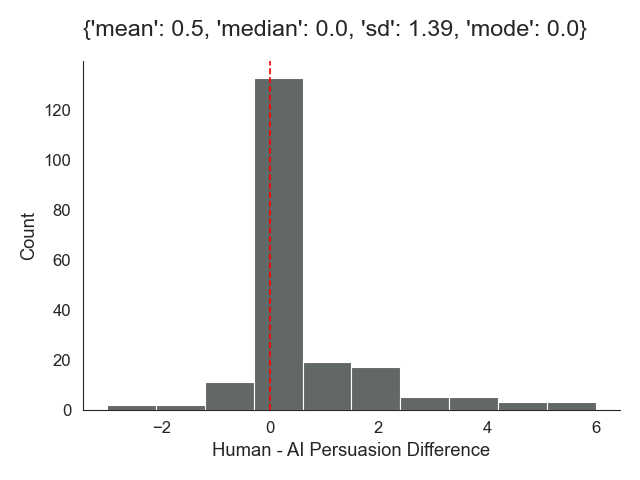

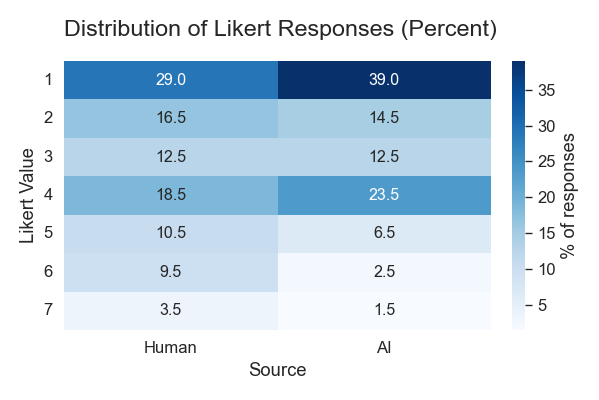

In [252]:
import seaborn as sns
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)

sum_stats = {
    'compel_human': array_stats(df_wide['compel_human'].values),
    'compel_ai': array_stats(df_wide['compel_ai'].values),
    'compel_human_diff': array_stats(df_wide['compel_human_diff'].values),
}

human_compel = df_wide['compel_human'].values
ai_compel = df_wide['compel_ai'].values
compel_diffs = df_wide['compel_human_diff'].values

# Statistical Analysis
###################################
wilcox_results = wilcox_test(compel_diffs)
print_wilcox(wilcox_results, "Human vs AI Persuasion (Wilcoxon)")

ttest_results = ttest_constant(compel_diffs)
print_ttest(ttest_results, "Human vs AI Persuasion (t-test)")

# Histogram of differences
###################################
sns.histplot(compel_diffs, bins=10)
plt.xlabel("Human - AI Persuasion Difference")
plt.title(sum_stats['compel_human_diff'])
plt.axvline(0, color='red', linestyle='--')
plt.show()

# Comparative heatmap
###################################
likert_scale = range(1, 8)
data = {
    'Human': pd.Series(df_wide['compel_human']).value_counts(normalize=True).reindex(likert_scale, fill_value=0) * 100,
    'AI': pd.Series(df_wide['compel_ai']).value_counts(normalize=True).reindex(likert_scale, fill_value=0) * 100
}
heatmap_df = pd.DataFrame(data, index=likert_scale)
plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': '% of responses'})
plt.ylabel("Likert Value")
plt.xlabel("Source")
plt.title("Distribution of Likert Responses (Percent)")
plt.yticks(rotation=0)
plt.show()

## Do these human vs AI differences vary by dataset, domain, or agreement condition?

Putting these into a regression, it seems people are more likely to listen to AI over humans for normbank.

/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1955344246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='compel_human_diff', x=variable, data=df_wide, palette=mypal)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1955344246.py:5: UserWarning: The palette list has more values (15) than needed (2), which may not be intended.
  sns.barplot(y='compel_human_diff', x=variable, data=df_wide, palette=mypal)


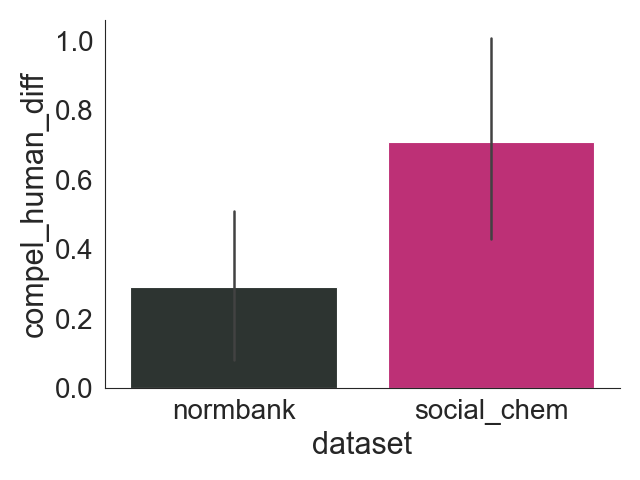

/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1955344246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='compel_human_diff', x=variable, data=df_wide, palette=mypal)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1955344246.py:5: UserWarning: The palette list has more values (15) than needed (3), which may not be intended.
  sns.barplot(y='compel_human_diff', x=variable, data=df_wide, palette=mypal)



ANALYSIS BY DATASET

DATASET = NORMBANK
W = 79.500, p = 0.007283
Cohen's dz = 0.272, n = 100
Significant: True

DATASET = SOCIAL_CHEM
W = 103.000, p = 0.000030
Cohen's dz = 0.438, n = 100
Significant: True


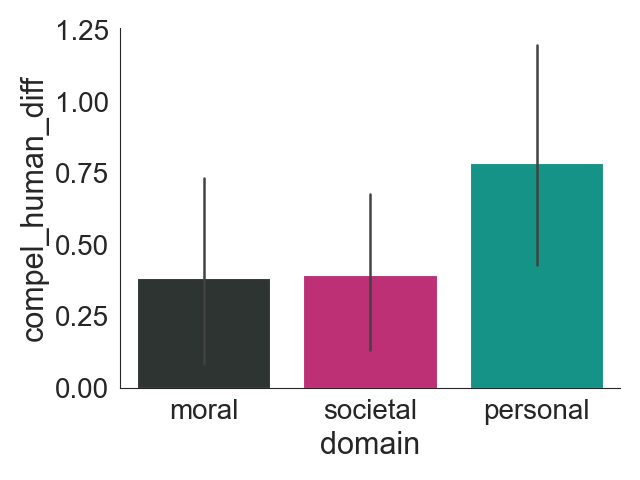


ANALYSIS BY DOMAIN

DOMAIN = MORAL
W = 65.000, p = 0.043222
Cohen's dz = 0.273, n = 60
Significant: True

DOMAIN = PERSONAL
W = 7.000, p = 0.000223
Cohen's dz = 0.538, n = 56
Significant: True

DOMAIN = SOCIETAL
W = 66.000, p = 0.007631
Cohen's dz = 0.300, n = 84
Significant: True


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1955344246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='compel_human_diff', x=variable, data=df_wide, palette=mypal)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1955344246.py:5: UserWarning: The palette list has more values (15) than needed (3), which may not be intended.
  sns.barplot(y='compel_human_diff', x=variable, data=df_wide, palette=mypal)


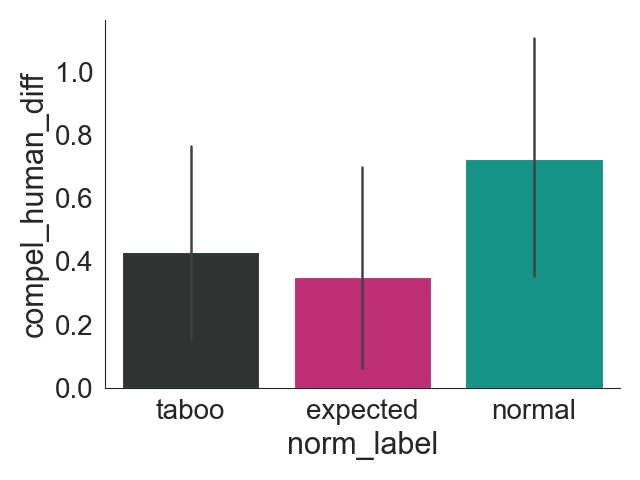


ANALYSIS BY NORM_LABEL

NORM_LABEL = EXPECTED
W = 28.500, p = 0.037953
Cohen's dz = 0.272, n = 63
Significant: True

NORM_LABEL = NORMAL
W = 46.000, p = 0.000523
Cohen's dz = 0.468, n = 65
Significant: True

NORM_LABEL = TABOO
W = 53.000, p = 0.004784
Cohen's dz = 0.329, n = 72
Significant: True

Regression on Human-AI Persuasion Difference


/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/src/statsmodels_handler.py:85: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sum_res = pd.read_html(self.model.summary().tables[1].as_html(), header=0, index_col=0)[0].reset_index()
/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/src/statsmodels_handler.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(y='var', x='coef', data=sum_res, capsize=0.1,
/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/src/statsmodels_handler.py:85: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object

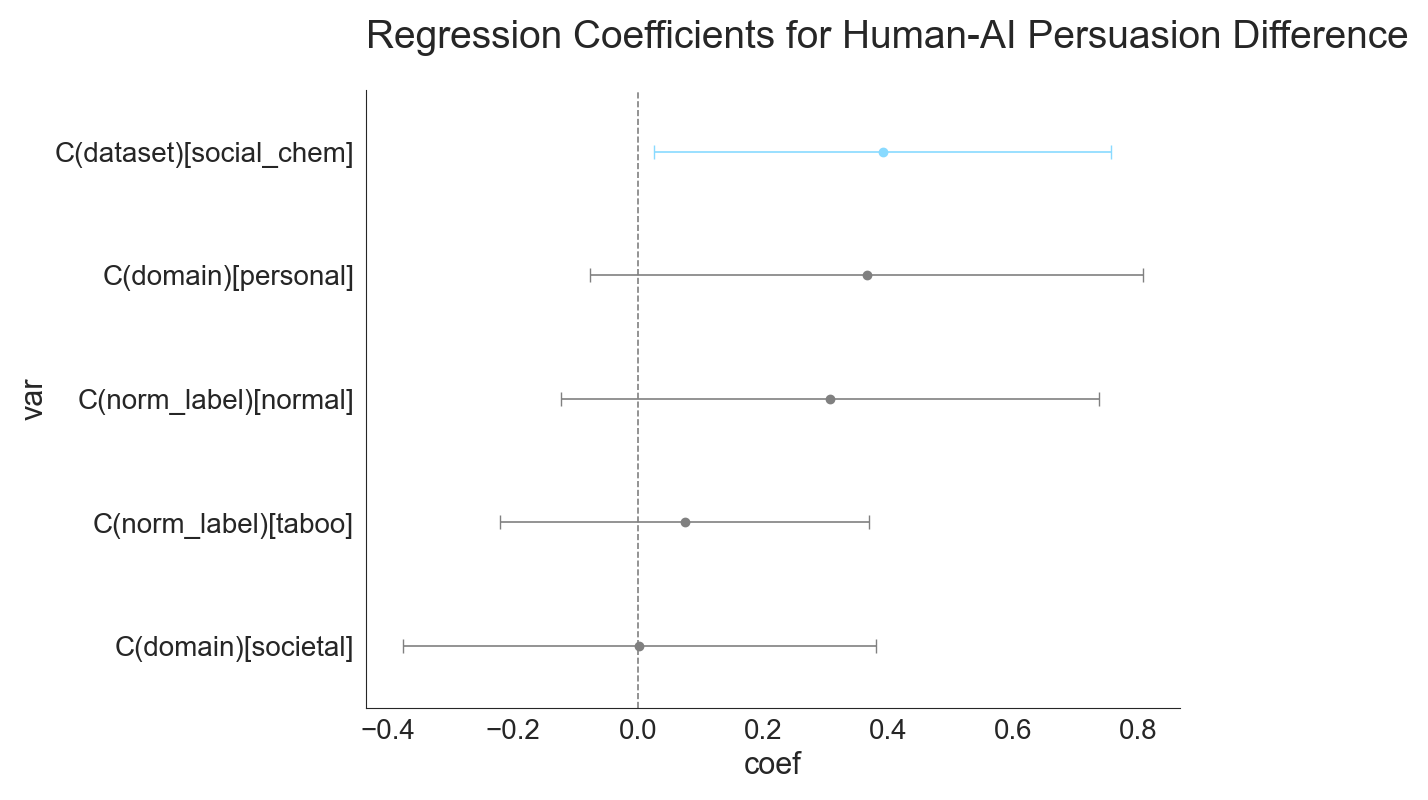

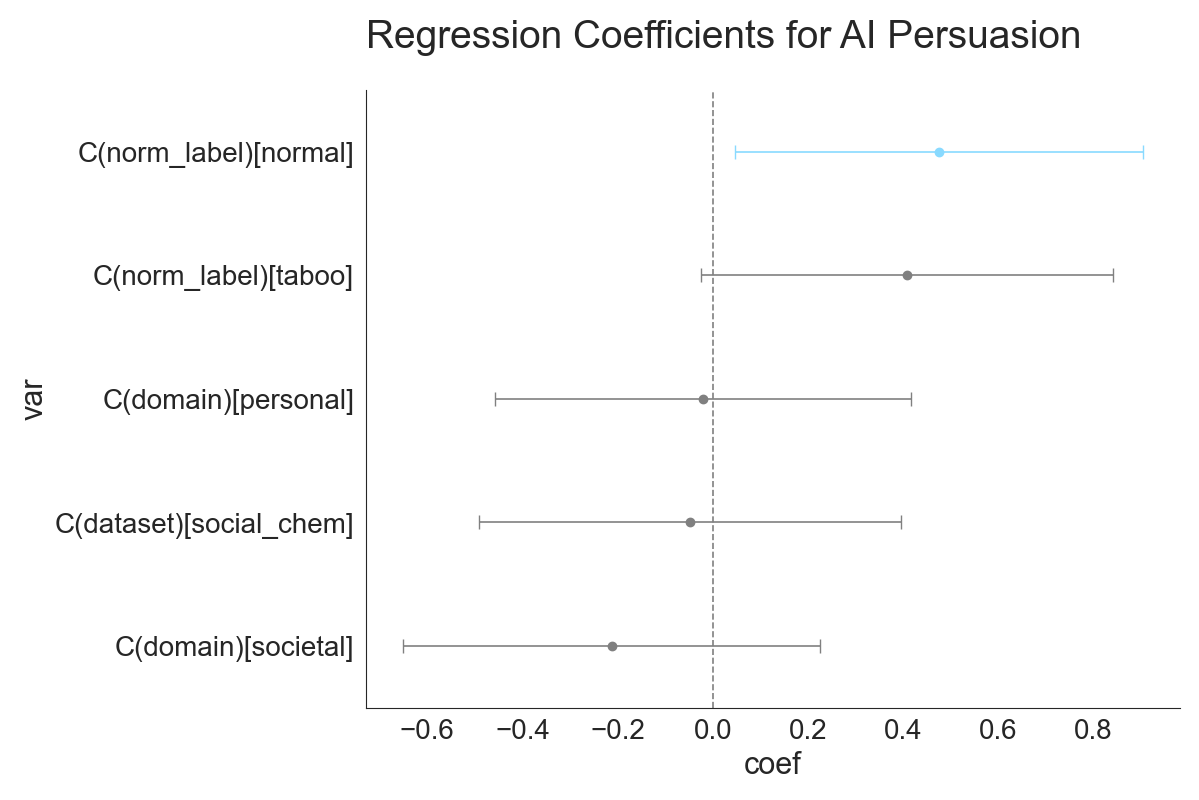

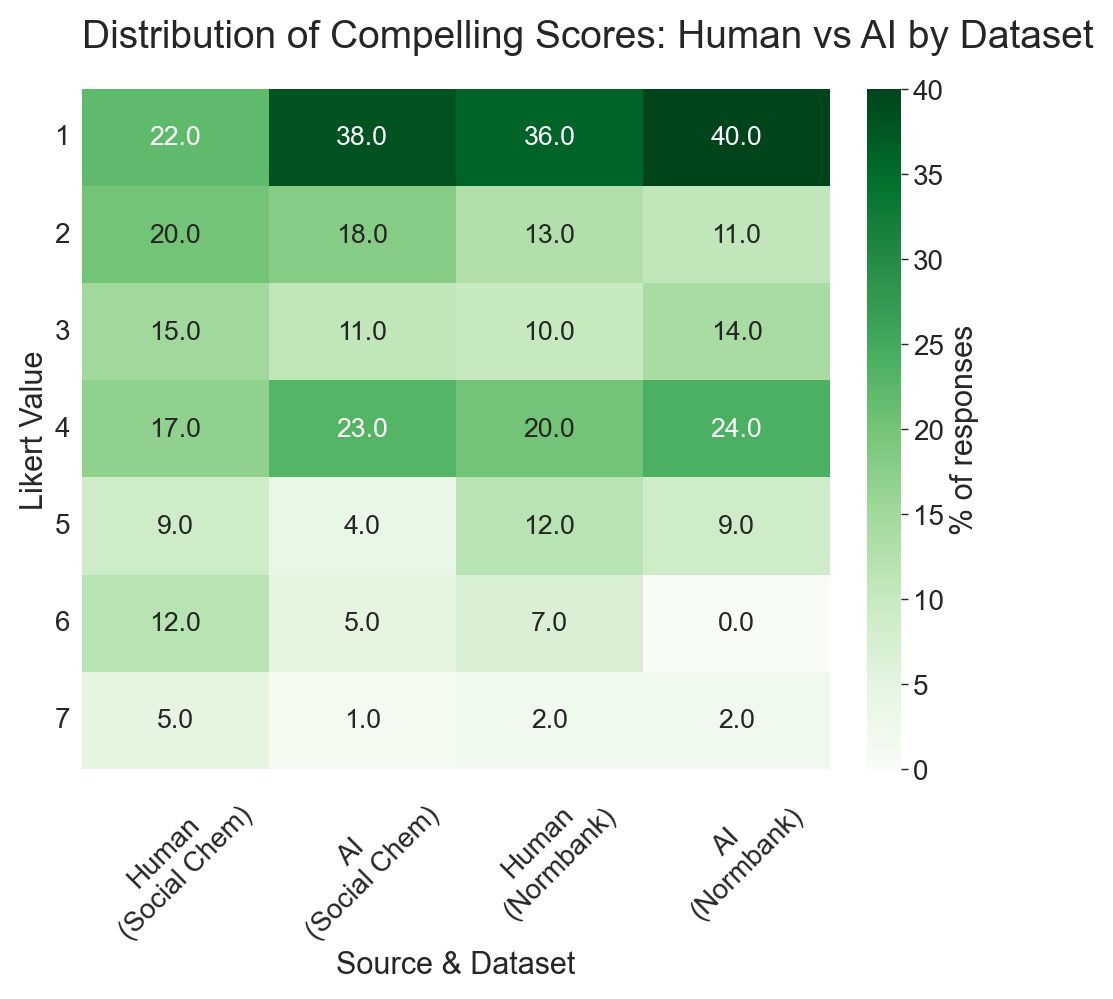

In [267]:
import statsmodels.formula.api as smf
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula

for variable in ['dataset', 'domain', 'norm_label']:
    sns.barplot(y='compel_human_diff', x=variable, data=df_wide, palette=mypal)
    plt.show()

    print(f"\nANALYSIS BY {variable.upper()}")
    grouped = df_wide.groupby(variable)['compel_human_diff'].apply(list).reset_index()

    for _, row in grouped.iterrows():
        var_value = row[variable]
        diffs = row['compel_human_diff']
        wilcox_results = wilcox_test(diffs)
        print_wilcox(wilcox_results, f"{variable} = {var_value}")



# Human-AI Persuasion Difference Regression
############################################
############################################
print("\nRegression on Human-AI Persuasion Difference")
df_reg = df_wide.dropna(subset=['compel_human_diff', 'dataset', 'domain', 'norm_label', 'pid']).copy()
model = smf.ols('compel_human_diff ~ C(dataset) + C(domain) + C(norm_label)', data=df_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['pid']}
)
make_aesthetic(font_scale=2)
handler = StatsmodelsHandler(model=model)
ax = handler.plot(figsize=(12,8), clean_var_name = clean_var_name_from_formula)
plt.title("Regression Coefficients for Human-AI Persuasion Difference")


# AI Persuasion Difference Regression
############################################
############################################
df_reg = df_wide.dropna(subset=['compel_human_diff', 'dataset', 'domain', 'norm_label', 'pid']).copy()
model = smf.ols('compel_ai ~ C(dataset) + C(domain) + C(norm_label)', data=df_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['pid']}
)
make_aesthetic(font_scale=2)
handler = StatsmodelsHandler(model=model)
ax = handler.plot(figsize=(12,8), clean_var_name = clean_var_name_from_formula)
plt.title("Regression Coefficients for AI Persuasion")






#  Four-way comparison (Human/AI x Social_Chem/Normbank)
###################################
social_chem_data = df_wide[df_wide['dataset'] == 'social_chem']
normbank_data = df_wide[df_wide['dataset'] == 'normbank']

data_four_way = {
    'Human\n(Social Chem)': social_chem_data['compel_human'].value_counts(normalize=True).reindex(likert_scale, fill_value=0) * 100,
    'AI\n(Social Chem)': social_chem_data['compel_ai'].value_counts(normalize=True).reindex(likert_scale, fill_value=0) * 100,
    'Human\n(Normbank)': normbank_data['compel_human'].value_counts(normalize=True).reindex(likert_scale, fill_value=0) * 100,
    'AI\n(Normbank)': normbank_data['compel_ai'].value_counts(normalize=True).reindex(likert_scale, fill_value=0) * 100
}
heatmap_df_four = pd.DataFrame(data_four_way, index=likert_scale)
plt.figure(figsize=(10, 10))
sns.heatmap(heatmap_df_four, annot=True, fmt=".1f", cmap="Greens", cbar_kws={'label': '% of responses'})
plt.ylabel("Likert Value")
plt.xlabel("Source & Dataset")
plt.title("Distribution of Compelling Scores: Human vs AI by Dataset")
plt.yticks(rotation=0)
plt.xticks(rotation=45)

plt.show()

# Which dataset is more straightforward to answer at a trial level?

Both equal.


{'t': 1.149333029835658, 'p': 0.2518056510190933, 'd': 0.16254023584769486, 'n1': 100, 'n2': 100}


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1215886448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='straight', x='dataset', data=df_wide, palette=mypal)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/1215886448.py:2: UserWarning: The palette list has more values (15) than needed (2), which may not be intended.
  sns.barplot(y='straight', x='dataset', data=df_wide, palette=mypal)


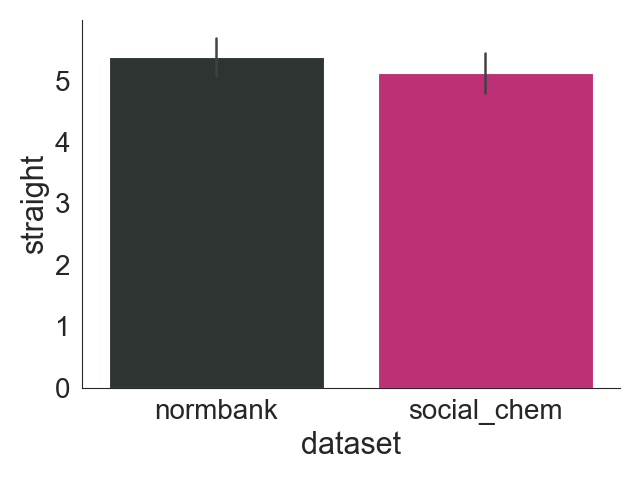

In [254]:
# Plot barplot of 'straight' by 'dataset'
sns.barplot(y='straight', x='dataset', data=df_wide, palette=mypal)

# Run t-test between the two datasets
print(ttest_2samples(
    df_wide[df_wide['dataset'] == 'normbank']['straight'],
    df_wide[df_wide['dataset'] == 'social_chem']['straight']
))

# Which dataset do participants explicitly say they'd rely on AI more for---general rules of thumb or specific behaviors? And which is more natural to answer

No difference in naturalness, but people say they would rely on AI more for general rules of thumb than specific behaviors with a small effect size (d=0.25)



In [255]:
def clean_which_natural(x):
    if x=="No preference":
        return 0
    elif x =="Somewhat prefer specific behavior":
        return -1
    elif x =="Much prefer specific behavior":
        return -2
    elif x =="Somewhat prefer general rules of thumb":
        return 1
    elif x =="Much prefer general rules of thumb":
        return 2
    else:
        return np.nan


def clean_which_ai(x):
    if x=="No preference":
        return 0
    elif x =="Prefer AI for general rules of thumb":
        return 1
    elif x =="Strongly prefer AI for general rules of thumb":
        return 2
    elif x =="Prefer AI for specific behavior":
        return -1
    elif x =="Strongly prefer AI for specific behavior":
        return -2
    else:
        return np.nan

print("WHICH IS MORE NATURAL TO ANSWER?")
dfp = df_wide.drop_duplicates(subset=['pid'])
dfp['which_natural_int'] = dfp['which_natural'].map(clean_which_natural)
print(array_stats(dfp['which_natural_int'],  include_ci=True))

print("WHICH WOULD YOU RELY ON AI MORE FOR?")
dfp['which_ai_int'] = dfp['which_ai'].map(clean_which_ai)
print(array_stats(dfp['which_ai_int'],  include_ci=True))


WHICH IS MORE NATURAL TO ANSWER?
M = 0.00, SD = 0.92, Mdn = 0.00
Mode = 0.00
95% CI [-0.40, 0.40]
{'mean': 0.0, 'median': 0.0, 'sd': 0.92, 'mode': 0, 'ci': (-0.4, 0.4)}
WHICH WOULD YOU RELY ON AI MORE FOR?
M = 0.50, SD = 0.89, Mdn = 0.00
Mode = 0.00
95% CI [0.15, 0.90]
{'mean': 0.5, 'median': 0.0, 'sd': 0.89, 'mode': 0, 'ci': (0.15, 0.9)}


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/3480895281.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['which_natural_int'] = dfp['which_natural'].map(clean_which_natural)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_11566/3480895281.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['which_ai_int'] = dfp['which_ai'].map(clean_which_ai)


# Qualitative analysis of open-ended responses

## Answers to the question of whether you would rely on AI more for general rules of thumb or specific behaviors

In [230]:
qual_final = df_wide.dropna(subset=['which_ai_qual']).drop_duplicates(subset=['pid'])
for idx, row in qual_final.iterrows():
    print(f"PID: {row['pid']}")
    print(f"Which AI would you rely on more for?: {row['which_ai']}")
    print(f"Response: {row['which_ai_qual']}")
    print("---")

PID: 6643a8837540ee80f2d5be45
Which AI would you rely on more for?: Prefer AI for general rules of thumb
Response: I think the human aspect is more beneficial on both sides or both rules above. There's an emotional context with each statement but cannot be understood by a chatbot
---
PID: 675a5ad39c319c39e7753011
Which AI would you rely on more for?: Strongly prefer AI for general rules of thumb
Response: I think specific behaviors is too difficult for AI to be helpful, its a lot of situational data it won't have or will struggle with.
---
PID: 67eda7cef014b05ef5504c28
Which AI would you rely on more for?: No preference
Response: I do not use large language models in any of those kinds of ways. Although, I use them every day. I use them to increase my productivity, do research and assisting with various coding projects. I am also continually educating myself on machine learning an artificial intelligence, prompt engineering, context engineering, automations, emergent behavior and ect..

## Trial level data where people are explaining why they would/would not listen to a chatbot for specific stimuli

In [262]:
def summarize_row(row):
    print(f"PID: {row['pid']}")
    print(f"ID", row['pid_stimuli'])
    print(f"Dataset: {row['dataset']}")
    print(f"Would listen to AI (1-7): {row['compel_ai']}")
    print(f"Stimulus: {row['shown_stimulus']}")
    print(f"Response: {row['qual_why']}")
    print("---")

qual_final = df_wide.dropna(subset=['qual_why'])
would_listen_ai = qual_final[qual_final['compel_ai']> 3]
would_not_listen_ai = qual_final[qual_final['compel_ai']<=3]

print("SAMPLES OF PEOPLE WHO WOULD LISTEN TO AI (>3)")
print("===============================")
for idx, row in would_listen_ai.iterrows():
    summarize_row(row)
print("===============================")


print("SAMPLES OF PEOPLE WHO WOULD NOT LISTEN TO AI (<=3")
print("===============================")
for idx, row in would_not_listen_ai.iterrows():
    summarize_row(row)
print("===============================")


SAMPLES OF PEOPLE WHO WOULD LISTEN TO AI (>3)
PID: 606492360e422d12dc63000e
ID 606492360e422d12dc63000e-8-normbank
Dataset: normbank
Would listen to AI (1-7): 4.0
Stimulus: Deprive the suspect of sleep in an interrogation room when you are an interrogator
Response: I need a more human argument with conviction, not just facts.
---
PID: 6643a8837540ee80f2d5be45
ID 6643a8837540ee80f2d5be45-10-normbank
Dataset: normbank
Would listen to AI (1-7): 4.0
Stimulus: Kick someone in the head at a boxing hall when you are a fighter
Response: The chat bot is based more on facts than it is on the emotions behind the app so it would definitely be helpful to know more of the facts
---
PID: 6643a8837540ee80f2d5be45
ID 6643a8837540ee80f2d5be45-37-social_chem
Dataset: social_chem
Would listen to AI (1-7): 4.0
Stimulus: It is wrong to purposely try to be like your best friend.
Response: I'm sure the chat bot could give many reasons why minis to statistical reasons but a human being could give emotional rea

# Differences in SDs of agreement by dataset and item?

Here we create buckets of (dataset, idx) and look at the std of agreement within each bucket. No differences.

{'t': 0.6586415801877948, 'p': 0.5128195928422727, 'd': 0.17179092391355957, 'n1': 29, 'n2': 30}


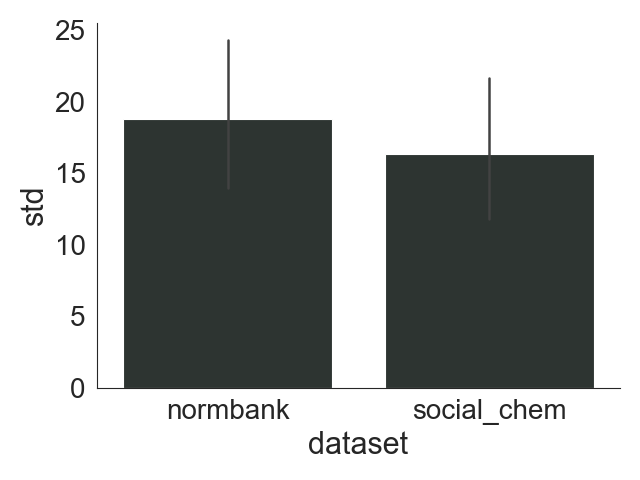

In [243]:
bucket = df_wide.groupby(by=['dataset', 'idx'])['agree'].agg(['mean', 'std', 'count']).reset_index()
bucket = bucket.query("count>1")
sns.barplot(data=bucket, x='dataset', y='std')

normbank_sds = bucket[bucket['dataset']=='normbank']['std']
socialchem_sds = bucket[bucket['dataset']=='social_chem']['std']
print(ttest_2samples(normbank_sds, socialchem_sds))

In [244]:
df_wide.columns

Index(['pid', 'pid_stimuli', 'lm_num', 'dataset', 'llm_usage', 'viewing_order',
       'which_ai', 'which_natural', 'which_ai_qual', 'agree', 'straight',
       'compel_ai', 'compel_human', 'compel_human_diff', 'qual_why',
       'social_chemistry_stimulus_rewrite', 'normbank_stimulus_rewrite',
       'social_chemistry_stimulus', 'normbank_stimulus', 'domain',
       'norm_label', 'idx', 'which_natural_int', 'which_ai_int'],
      dtype='object')